<a href="https://colab.research.google.com/github/john891212-oss/AIFFEL_quest_eng/blob/main/NLP/NLP04/miniBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 프로젝트 : mini BERT 만들기

vocab size를 8000으로 줄이고, 전체 파라미터 사이즈가 1M 정도가 되는 아주 작은 mini BERT 모델을 만들어 10 Epoch까지 학습시킨 모델을 만들어 보는 것입니다.

구현 흐름: 데이터 다운로드 => 환경설정 => 토크나이징 => 데이터 전처리 => 모델 구현 => 학습 => loss & metric 측정

목차   
1. 환경설정
2. 데이터 다운로드
3. SentencePiece tokenizer 학습
4. BERT pretrain 데이터 전처리
5. mini BERT 모델 구현
6. MLM + NSP 학습
7. Loss & Metric 측정
8. 결과 정리

In [5]:
# imports
from __future__ import absolute_import, division, print_function, unicode_literals

import os
import re
import math
import random
import collections
import json
import shutil
import zipfile
import copy
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import sentencepiece as spm
from tqdm.auto import tqdm

random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)

# torch version
print(torch.__version__)

2.10.0+cu128


## 환경설정  

In [6]:
# epoch은 10으로 설정했습니다.
# 배치 사이즈는 16입니다.
# vocab size 8000 입니다
# 전체 데이터로 오래 학습하려면 아래 값을 "0"으로 바꾸면 됩니다.
os.environ.setdefault("BERT_PRETRAIN_FAST_RUN", "0")
os.environ.setdefault("BERT_PRETRAIN_MAX_LINES", "20000")
os.environ.setdefault("BERT_PRETRAIN_COUNT", "20000")
os.environ.setdefault("BERT_PRETRAIN_EPOCHS", "10")
os.environ.setdefault("BERT_PRETRAIN_BATCH_SIZE", "16")
os.environ.setdefault("BERT_PRETRAIN_SP_VOCAB_SIZE", "8000")

'8000'

In [7]:
# Colab 모두 실행용 셋업 셀
# 이 셀은 런타임 → 모두 실행을 눌렀을 때 필요한 파일/폴더/패키지를 자동으로 준비합니다.

import os
import sys
import subprocess
import zipfile
import urllib.request
from pathlib import Path

## 데이터 다운로드 및 8000 사이즈 vocab 생성

In [8]:
# 패키지 설치
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "sentencepiece", "tqdm", "torchinfo"
])

BASE_DIR = Path("/content") if Path("/content").exists() else Path.cwd()
os.chdir(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
MODEL_DIR = BASE_DIR / "models"
WORK_DIR = BASE_DIR / "work"
for path in (DATA_DIR, MODEL_DIR, WORK_DIR):
    path.mkdir(parents=True, exist_ok=True)

CORPUS_URL = "https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip"
zip_path = DATA_DIR / "kowiki.txt.zip"
corpus_path = DATA_DIR / "kowiki.txt"

# corpus 다운로드 및 압축 해제
if not corpus_path.exists():
    try:
        if not zip_path.exists():
            print("Downloading kowiki.txt.zip...")
            urllib.request.urlretrieve(CORPUS_URL, zip_path)

        print("Extracting kowiki.txt.zip...")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(DATA_DIR)

        found = list(DATA_DIR.rglob("kowiki.txt"))
        if found:
            found_path = found[0]
            if found_path != corpus_path:
                corpus_path.write_text(found_path.read_text(encoding="utf-8"), encoding="utf-8")
    except Exception as e:
        print("kowiki.txt 다운로드에 실패해 샘플 corpus로 대체합니다.")
        print("실제 학습을 하려면 data/kowiki.txt를 직접 업로드하세요.")
        sample_text = """
인공지능은 컴퓨터가 사람처럼 학습하고 추론하도록 만드는 기술이다.
자연어 처리는 사람이 사용하는 언어를 컴퓨터가 이해하도록 만드는 분야이다.
BERT는 Transformer encoder 구조를 기반으로 만들어진 언어 모델이다.
Masked Language Modeling은 일부 토큰을 가리고 원래 토큰을 맞히는 학습 방식이다.
Next Sentence Prediction은 두 문장이 이어지는지 판단하는 학습 방식이다.

딥러닝 모델은 많은 데이터를 사용하여 패턴을 학습한다.
토크나이저는 문장을 작은 단위의 토큰으로 나누는 역할을 한다.
SentencePiece는 subword 기반 토크나이저를 만들 때 자주 사용된다.
""".strip()
        corpus_path.write_text((sample_text + "\n\n") * 2000, encoding="utf-8")

# 빠른 실행 모드에서는 corpus 일부만 사용합니다.
fast_run = os.environ.get("BERT_PRETRAIN_FAST_RUN", "1") == "1"
if fast_run:
    max_lines = int(os.environ.get("BERT_PRETRAIN_MAX_LINES", "20000"))
    run_corpus_path = DATA_DIR / "kowiki_colab_small.txt"
    if not run_corpus_path.exists():
        print(f"Creating small corpus for fast run: first {max_lines} lines")
        with open(corpus_path, "r", encoding="utf-8") as in_f, open(run_corpus_path, "w", encoding="utf-8") as out_f:
            for i, line in enumerate(in_f):
                if i >= max_lines:
                    break
                out_f.write(line)
else:
    run_corpus_path = corpus_path

os.environ["BERT_PRETRAIN_CORPUS_FILE"] = str(run_corpus_path)

# SentencePiece 모델이 없으면 자동 생성합니다.
# 빠른 실행을 위해 기본 vocab size는 8000으로 둡니다.
import sentencepiece as spm
model_path = DATA_DIR / "ko_8000.model"
if not model_path.exists() and not (MODEL_DIR / "ko_8000.model").exists():
    sp_vocab_size = int(os.environ.get("BERT_PRETRAIN_SP_VOCAB_SIZE", "8000"))
    prefix = DATA_DIR / "ko_8000"
    print(f"Training SentencePiece model. vocab_size={sp_vocab_size + 7}")
    spm.SentencePieceTrainer.train(
        f"--input={run_corpus_path} "
        f"--model_prefix={prefix} "
        f"--vocab_size={sp_vocab_size + 7} "
        "--model_type=bpe "
        "--max_sentence_length=999999 "
        "--pad_id=0 --pad_piece=[PAD] "
        "--unk_id=1 --unk_piece=[UNK] "
        "--bos_id=2 --bos_piece=[BOS] "
        "--eos_id=3 --eos_piece=[EOS] "
        "--user_defined_symbols=[SEP],[CLS],[MASK] "
        "--hard_vocab_limit=false"
    )

print("Colab setup finished.")
print("corpus_file:", os.environ["BERT_PRETRAIN_CORPUS_FILE"])
print("fast_run:", fast_run)
print("train_count:", os.environ["BERT_PRETRAIN_COUNT"])
print("epochs:", os.environ["BERT_PRETRAIN_EPOCHS"])
print("batch_size:", os.environ["BERT_PRETRAIN_BATCH_SIZE"])

Extracting kowiki.txt.zip...
Training SentencePiece model. vocab_size=8007
Colab setup finished.
corpus_file: /content/data/kowiki.txt
fast_run: False
train_count: 20000
epochs: 10
batch_size: 16


패키지 설치와 데이터 다운로드 그리고 8000사이즈 vocab setencepieace model 생성  
생성된 모델에는 특수 코인 7가지도 포함 시키고 로드합니다.

In [9]:
import sentencepiece as spm
from pathlib import Path

# Colab setup cell에서 지정한 corpus 파일을 사용합니다.
data_dir = Path("data")
model_dir = Path("models")
corpus_file = Path(os.environ.get("BERT_PRETRAIN_CORPUS_FILE", str(data_dir / "kowiki.txt")))
prefix = data_dir / "ko_8000"
vocab_size = 8000

In [10]:
# vocab loading
candidate_model_paths = [
    data_dir / "ko_8000.model",
    model_dir / "ko_8000.model",
]
model_path = next((path for path in candidate_model_paths if path.exists()), None)

if model_path is None:
    raise FileNotFoundError(
        "ko_8000.model을 찾을 수 없습니다. "
        "첫 번째 Colab setup cell이 정상적으로 실행되었는지 확인하세요."
    )

vocab = spm.SentencePieceProcessor()
vocab.load(str(model_path))
REAL_VOCAB_SIZE = vocab.get_piece_size()
print("Loaded SentencePiece model:", model_path)
print("REAL_VOCAB_SIZE:", REAL_VOCAB_SIZE)

Loaded SentencePiece model: data/ko_8000.model
REAL_VOCAB_SIZE: 8007


토큰 출력 확인

In [11]:
# Q. 특수 token 7개를 제외한 나머지 token들을 출력해봅시다.
vocab_list = []
for token_id in range(7, vocab.get_piece_size()):
    if not vocab.is_unknown(token_id):
        vocab_list.append(vocab.id_to_piece(token_id))

print("vocab_list size:", len(vocab_list))
print(vocab_list[:100])

vocab_list size: 8000
['▁1', '▁이', '으로', '에서', '▁있', '▁2', '▁그', '▁대', '▁사', '이다', '었다', '▁지', '▁수', '▁19', '▁가', '▁시', '▁20', '▁기', '▁전', '▁아', '▁하', '▁있다', '▁다', '▁제', '했다', '하였', '▁일', '▁한', '▁중', '▁정', '▁주', '하는', '▁것', '▁자', '▁공', '▁인', '되었다', '▁경', '▁위', '▁유', '▁보', '하고', '▁3', '▁등', '▁부', '하였다', '▁조', '하여', '▁미', '▁동', '▁선', '▁나', '으며', '▁모', '▁연', '▁영', '▁의', '▁오', '▁마', '에는', '▁발', '▁소', '한다', '▁고', '▁개', '▁201', '▁구', '▁세', '▁도', '▁상', '▁비', '▁스', '▁국', '▁서', '▁후', '▁여', '▁200', '▁때', '▁4', '▁성', '▁해', '▁관', '▁있는', '▁신', '▁프', '▁대한', '부터', '▁5', '00', '▁방', '▁또', '지만', '▁(', '▁역', '되어', '▁않', '▁만', '▁"', '▁장', '▁바']


특수 토큰이 들어가는 입력용 setence pair 생성

In [12]:
# [CLS], tokens a, [SEP], tokens b, [SEP] 형태의 token 생성
string_a = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아 첫 번에 삼십 전 둘째번 오십 전 오랜만에 받아보는 십 전짜리 백통화 서푼에"
string_b = "손바닥 위엔 기쁨의 눈물이 흘러 컬컬한 목에 모주 한잔을 적셔 몇 달 포 전부터 콜록거리는 아내 생각에 그토록 먹고 싶다던"
tokens_org = ["[CLS]"] + vocab.encode_as_pieces(string_a) + ["[SEP]"] + vocab.encode_as_pieces(string_b) + ["[SEP]"]
print(tokens_org)

['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]']


## 데이터 전처리
### (1) 마스킹

BERT의 MLM에 필요한 빈칸(mask)을 학습 데이터 전체 토큰의 15% 정도로 만들고  
 그 중 80%는 [MASK] 토큰, 10%는 랜덤한 토큰, 나머지 10%는 원래의 토큰을 그대로 사용

In [13]:
import random

def create_pretrain_mask(tokens, mask_cnt, vocab_list, rng=None):
    """
    BERT MLM용 mask 생성 함수

    Args:
        tokens: 원본 token list
                예: ["[CLS]", "▁나는", "▁밥", "을", "▁먹었다", "[SEP]"]
        mask_cnt: masking할 token 개수
        vocab_list: random token 선택용 vocab list
        rng: 재현성을 위한 random 객체

    Returns:
        tokens_masked: mask가 적용된 token list
        mask_idx: mask된 위치 index list
        mask_label: mask된 위치의 원래 token list
    """
    rng = rng or random

    tokens_masked = list(tokens)

    # [CLS], [SEP], [PAD] 같은 특수 토큰은 mask 대상에서 제외
    special_tokens = {"[CLS]", "[SEP]", "[PAD]", "[BOS]", "[EOS]"}

    candidate_indices = [
        i for i, token in enumerate(tokens)
        if token not in special_tokens
    ]

    rng.shuffle(candidate_indices)

    mask_cnt = min(mask_cnt, len(candidate_indices))
    mask_idx = sorted(candidate_indices[:mask_cnt])

    mask_label = []

    for idx in mask_idx:
        original_token = tokens[idx]
        mask_label.append(original_token)

        prob = rng.random()

        if prob < 0.8:
            # 80%는 [MASK] 토큰으로 변경
            tokens_masked[idx] = "[MASK]"

        elif prob < 0.9:
            # 10%는 랜덤 토큰으로 변경
            tokens_masked[idx] = rng.choice(vocab_list)

        else:
            # 10%는 원래 토큰 그대로 유지
            tokens_masked[idx] = original_token

    return tokens_masked, mask_idx, mask_label

In [14]:
# 전체 token 중 약 15%를 mask
mask_cnt = max(1, int(round(len(tokens_org) * 0.15)))

# SentencePiece vocab list 만들기
vocab_list = [vocab.id_to_piece(i) for i in range(vocab.get_piece_size())]

tokens_masked, mask_idx, mask_label = create_pretrain_mask(
    tokens=tokens_org,
    mask_cnt=mask_cnt,
    vocab_list=vocab_list
)

print("원본 tokens:")
print(tokens_org)

print("\nmask 적용 tokens:")
print(tokens_masked)

print("\nmask index:")
print(mask_idx)

print("\nmask label:")
print(mask_label)

원본 tokens:
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘', '째', '번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]']

mask 적용 tokens:
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '[MASK]', '[MASK]', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '索', '이', '[MASK]', '아', '▁첫', '▁번', '에', '▁삼', '[MASK]', '[MASK]', '▁둘', '째', '번', '▁오', '십', '▁전', '▁오', '랜', '만에', '▁받아', '보', '는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '[MASK]', '닥', '[MASK]', '엔', '[MASK]', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모',

### (2) NSP pair 생성

BERT의 NSP task를 수행을 위해 문장 전후 관계를 알수 있도록 나눠서 네거티브 셈플링을 해준다. isNext와 NoNext로 구별되게 한다.

In [15]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a와 tokens_b의 합친 길이가 max_seq 이하가 되도록 줄입니다.
    BERT 입력에서 [CLS], [SEP], [SEP]를 제외한 실제 문장 토큰 길이를 맞출 때 사용합니다.

    Args:
        tokens_a: 첫 번째 문장 token list
        tokens_b: 두 번째 문장 token list
        max_seq: len(tokens_a) + len(tokens_b)의 최대 길이
    """
    while len(tokens_a) + len(tokens_b) > max_seq:
        if len(tokens_a) > len(tokens_b):
            tokens_a.pop()
        else:
            tokens_b.pop()

doc 안에 있는 string을 BERT 학습용 instance로 만들어주는 함수   
앞서 정의한 마스킹 함수 역시 들어가 있다.

In [16]:
def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc별 pretrain 데이터 생성
    """
    # for [CLS], [SEP], [SEP]
    max_seq = n_seq - 3

    instances = []
    current_chunk = []
    current_length = 0

    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])

        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = random.randrange(1, len(current_chunk))

            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])

            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            # 실습 버전: 50% 확률로 두 문장 순서를 바꿔 NotNext negative sample 생성
            # 원 논문 BERT는 다른 문서의 random sentence를 사용합니다.
            if random.random() < 0.5:
                is_next = 0
                tokens_a, tokens_b = tokens_b, tokens_a
            else:
                is_next = 1

            # max_seq 보다 큰 경우 길이 조절
            trim_tokens(tokens_a, tokens_b, max_seq)
            if not tokens_a or not tokens_b:
                current_chunk = []
                current_length = 0
                continue

            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

            mask_cnt = max(1, int(round((len(tokens) - 3) * mask_prob)))
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)

            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            }
            instances.append(instance)

            current_chunk = []
            current_length = 0

    return instances

NSP 학습을 위해 문서 내 연속된 문장 chunk를 두 부분으로 나누어 sentence A와 sentence B를 구성하였다.
50% 확률로 원래 순서를 유지하여 is_next=1로 지정하고, 나머지 50%는 두 문장의 순서를 바꾸어 is_next=0으로 지정하였다.
입력 sequence는 [CLS] sentence A [SEP] sentence B [SEP] 형태로 구성하였고, sentence A 영역은 segment 0, sentence B 영역은 segment 1로 지정하였다.
이후 동일한 sequence에 대해 유효 토큰의 약 15%를 선택하여 MLM mask를 적용하였다.

## (3) 데이터셋 완성

In [17]:
import os
import json
from tqdm import tqdm

def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """
    BERT pretrain 데이터 생성 함수

    Args:
        vocab: SentencePieceProcessor
        in_file: 원본 corpus txt 파일 경로
        out_file: pretrain 데이터가 저장될 jsonl 파일 경로
        n_seq: 최대 sequence 길이
        mask_prob: MLM mask 비율, 기본값 0.15

    Output:
        json line 형식의 pretrain 데이터 파일
        각 line에는 tokens, segment, is_next, mask_idx, mask_label이 저장됨
    """

    # ------------------------------------------------------------
    # 1. 출력 폴더 생성
    # ------------------------------------------------------------
    out_dir = os.path.dirname(out_file)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    # ------------------------------------------------------------
    # 2. random replacement용 vocab list 생성
    # ------------------------------------------------------------
    # 앞의 7개 토큰은 특수 토큰이라고 가정
    # [PAD], [UNK], [BOS], [EOS], [SEP], [CLS], [MASK]
    local_vocab_list = []

    for token_id in range(7, vocab.get_piece_size()):
        if not vocab.is_unknown(token_id):
            local_vocab_list.append(vocab.id_to_piece(token_id))

    print("random vocab size:", len(local_vocab_list))

    # ------------------------------------------------------------
    # 3. doc 단위 pretrain instance 저장 함수
    # ------------------------------------------------------------
    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(
            vocab=vocab,
            doc=doc,
            n_seq=n_seq,
            mask_prob=mask_prob,
            vocab_list=local_vocab_list
        )

        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # ------------------------------------------------------------
    # 4. line count 확인
    # ------------------------------------------------------------
    line_cnt = 0

    with open(in_file, "r", encoding="utf-8") as in_f:
        for _ in in_f:
            line_cnt += 1

    # ------------------------------------------------------------
    # 5. corpus 읽으면서 doc 단위로 전처리
    # ------------------------------------------------------------
    doc = []

    with open(in_file, "r", encoding="utf-8") as in_f, \
         open(out_file, "w", encoding="utf-8") as out_f:

        for line in tqdm(in_f, total=line_cnt):
            line = line.strip()

            # 빈 줄이면 하나의 문서/단락이 끝났다고 봄
            if line == "":
                if len(doc) > 0:
                    save_pretrain_instances(out_f, doc)
                    doc = []

            # 빈 줄이 아니면 SentencePiece tokenize 후 doc에 추가
            else:
                pieces = vocab.encode_as_pieces(line)

                if len(pieces) > 0:
                    doc.append(pieces)

        # 마지막 doc 처리
        if len(doc) > 0:
            save_pretrain_instances(out_f, doc)

    print("pretrain data saved:", out_file)

corpus를 줄 단위로 읽고 빈 줄을 기준으로 하나의 doc을 구성하였다.
각 문장은 SentencePiece tokenizer를 이용해 token piece로 변환하였다.
doc 단위로 NSP pair를 만들고, 각 입력 sequence에 대해 MLM mask를 적용하였다.
생성된 pretrain instance는 json line 형식으로 저장하였다.

In [18]:
pretrain_json_path = 'work/bert_pre_train.json'

make_pretrain_data(vocab, corpus_file, pretrain_json_path, 128)

random vocab size: 8000


100%|██████████| 3957761/3957761 [05:08<00:00, 12812.55it/s]

pretrain data saved: work/bert_pre_train.json


만들어진 데이터는 용량이 크기 때문에 로딩할 함수를 만들도록 합니다.  
`np.memmap`을 사용해 메모리 효율적으로 만들어진 데이터를 로딩하는 함수를 아래와 같이 구성

In [19]:
def load_pre_train_data(vocab, filename, n_seq, count=None, memmap_dir="work/memmap"):
    """
    학습에 필요한 데이터를 로드
    :param vocab: vocab
    :param filename: 전처리된 json 파일
    :param n_seq: 시퀀스 길이 (number of sequence)
    :param count: 데이터 수 제한 (None이면 전체)
    :param memmap_dir: memmap 파일 저장 디렉토리
    :return enc_tokens: encoder inputs
    :return segments: segment inputs
    :return labels_nsp: nsp labels
    :return labels_mlm: mlm labels
    """
    os.makedirs(memmap_dir, exist_ok=True)

    total = 0
    with open(filename, "r", encoding="utf-8") as f:
        for _ in f:
            total += 1
            if count is not None and total >= count:
                break

    enc_tokens = np.memmap(filename=os.path.join(memmap_dir, "enc_tokens.memmap"), mode="w+", dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename=os.path.join(memmap_dir, "segments.memmap"), mode="w+", dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename=os.path.join(memmap_dir, "labels_nsp.memmap"), mode="w+", dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename=os.path.join(memmap_dir, "labels_mlm.memmap"), mode="w+", dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r", encoding="utf-8") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                print("data load early stop", total, i)
                break

            data = json.loads(line)

            # encoder token
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]][:n_seq]
            enc_token += [0] * (n_seq - len(enc_token))

            # segment
            segment = list(data["segment"])[:n_seq]
            segment += [0] * (n_seq - len(segment))

            # nsp label
            label_nsp = int(data["is_next"])

            # mlm label: 0은 unmasked/pad 위치이므로 loss에서 ignore_index로 제외
            label_mlm = np.zeros(n_seq, dtype=np.int32)
            for idx, label in zip(data["mask_idx"], data["mask_label"]):
                if 0 <= idx < n_seq:
                    label_mlm[idx] = vocab.piece_to_id(label)

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    for arr in (enc_tokens, segments, labels_nsp, labels_mlm):
        arr.flush()

    return (enc_tokens, segments), (labels_nsp, labels_mlm)

In [20]:
# Colab 모두 실행을 위해 기본값은 일부 데이터만 로딩합니다.
# 전체로 돌리고 싶으면 첫 번째 셀의 BERT_PRETRAIN_COUNT 값을 늘리면 됩니다.
train_count = int(os.environ.get("BERT_PRETRAIN_COUNT", "20000"))
pre_train_inputs, pre_train_labels = load_pre_train_data(vocab, pretrain_json_path, 128, count=train_count)
print("loaded train_count:", len(pre_train_inputs[0]))

100%|██████████| 20000/20000 [00:08<00:00, 2225.28it/s]


data load early stop 20000 20000
loaded train_count: 20000


In [21]:
pre_train_inputs[0][0], pre_train_inputs[0][-1], pre_train_inputs[1][0], pre_train_inputs[1][-1], pre_train_labels[0][0], pre_train_labels[0][-1], pre_train_labels[1][0], pre_train_labels[1][-1]

(memmap([   5,   18, 6787,  207, 3714, 3324, 1042,  104, 3610, 3686, 3718,
          207, 3714,   37, 3417,    6,    6, 3666, 3625,  160, 3662,    7,
            6,  203,    6, 3602, 1114, 3724,  788,  243,   49, 3632,    6,
          663,    6, 3682,    6, 3625,    6, 3009, 3625, 3616,   16, 3599,
            4,   18, 3686,  207, 3714, 3602, 1756, 3630, 3646,    6,    6,
         3568, 3835,    6, 3740, 3628, 3626, 1370,   10, 1607, 3599, 1756,
         3630,   41, 3644,  830, 3624, 1135,   52, 5950,   13,   81,   87,
            6, 2247,   25, 3779, 3873, 3667, 3631, 3813, 3873, 4196, 3636,
         3779, 3601,  249, 3725,    6,   33,   52, 3599,  479, 3652, 3625,
            6, 2780,   14, 1510,  168, 3877,  414,  166, 1697, 4290, 3873,
         3703, 3683,  593,    6, 5007,  399, 1928, 3607,  813,   17, 3599,
          307,  587,  930,  104, 4313, 4290,    4], dtype=int32),
 memmap([   5, 2481,    6, 4715,    6,    6, 1995,  138, 3817,    6,  146,
         3602,    6, 3633, 1411, 3

##  BERT 모델 구현

![](https://resources-public-prd.modulabs.co.kr/home-section/story-modulabs-articles-section/3e786308-562c-43fe-aacc-48feeb074dee.png)

3개의 embedding layer를 구현해봅시다.
먼저 유틸리티함수를 정의 합니다.

패딩 마스크와 디코더용 마스크

In [22]:
def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: True, other: False)
    """
    return (tokens == i_pad).unsqueeze(1)

def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask (ahead or pad: True, other: False)
    """
    n_seq = tokens.size(1)
    ahead_mask = torch.triu(
        torch.ones((n_seq, n_seq), dtype=torch.bool, device=tokens.device),
        diagonal=1
    ).unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = ahead_mask | pad_mask
    return mask

print("슝=3")

슝=3


Gelu 함수

In [23]:
def gelu(x):
    """
    gelu activation 함수
    :param x: 입력 값
    :return: gelu activation result
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

print("슝=3")

슝=3


weight 파라미터 초기화기능

In [24]:

def kernel_initializer(stddev=0.02):
    """
    weight parameter를 truncated normal로 초기화합니다.
    BERT 계열 모델에서는 보통 std=0.02를 사용합니다.
    """
    def init_weight(tensor):
        return torch.nn.init.trunc_normal_(
            tensor,
            mean=0.0,
            std=stddev,
            a=-2 * stddev,
            b=2 * stddev
        )
    return init_weight


def bias_initializer():
    """
    bias parameter를 0으로 초기화합니다.
    """
    return torch.zeros_

print("슝=3")

슝=3


config

In [25]:
class Config(dict):
    """
    json을 config 형태로 사용하기 위한 Class
    :param dict: config dictionary
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        """
        file에서 Config를 생성 함
        :param file: filename
        """
        with open(file, 'r') as f:
            config = json.loads(f.read())
            return Config(config)
print("슝=3")

슝=3


### embedding layer

BERT의 token embedding과 MLM 출력 layer의 weight를 공유하는 구조로 하나의 weight를 두 용도로 씁니다.   
이를 통해 embedding과 MLM classifier를 별도로 둘 때보다 약 n_vocab × d_model 만큼의 파라미터를 절약할 수 있습니다.

In [26]:
class SharedEmbedding(nn.Module):
    """
    Token embedding과 MLM output projection의 weight를 공유하는 layer
    """
    def __init__(self, config):
        super().__init__()

        self.n_vocab = config.n_vocab
        self.d_model = config.d_model

        self.shared_weights = nn.Parameter(
            torch.empty(self.n_vocab, self.d_model)
        )

        nn.init.trunc_normal_(
            self.shared_weights,
            mean=0.0,
            std=0.02
        )

    def forward(self, inputs, mode="embedding"):
        if mode == "embedding":
            return self.embedding(inputs)

        if mode == "linear":
            return self.linear(inputs)

        raise ValueError(f"Unknown mode: {mode}")

    def embedding(self, input_ids):
        """
        input_ids: (batch_size, n_seq)
        return   : (batch_size, n_seq, d_model)
        """
        return self.shared_weights[input_ids.long()]

    def linear(self, hidden_states):
        """
        hidden_states: (batch_size, n_seq, d_model)
        return       : (batch_size, n_seq, n_vocab)
        """
        return torch.matmul(hidden_states, self.shared_weights.T)

### Position Embedding 레이어

Position Embedding은 입력 token의 순서 정보를 모델에 제공하기 위해 사용하였다.
Transformer 구조는 recurrence나 convolution이 없기 때문에 token embedding만으로는 각 token의 위치를 알 수 없다.
따라서 0번 위치부터 n_seq-1번 위치까지 학습 가능한 position embedding을 만들고,
이를 token embedding 및 segment embedding과 더해 BERT encoder의 입력으로 사용하였다.

In [27]:
class PositionEmbedding(nn.Module):
    """
    학습 가능한 position embedding layer
    """
    def __init__(self, config):
        super().__init__()

        self.n_seq = config.n_seq
        self.d_model = config.d_model

        self.embedding = nn.Embedding(self.n_seq, self.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        """
        Args:
            inputs: token ids, shape = (batch_size, seq_len)

        Returns:
            position embedding, shape = (batch_size, seq_len, d_model)
        """
        batch_size, seq_len = inputs.size()

        if seq_len > self.n_seq:
            raise ValueError(
                f"sequence length {seq_len} exceeds config.n_seq={self.n_seq}"
            )

        positions = torch.arange(seq_len, device=inputs.device)
        positions = positions.unsqueeze(0).expand(batch_size, seq_len)

        return self.embedding(positions)

### scale dot product self attention  

In [28]:
class ScaledDotProductAttention(nn.Module):
    """
    Scaled Dot Product Attention

    Attention(Q, K, V) = softmax(QK^T / sqrt(d_k))V
    """
    def __init__(self):
        super().__init__()

    def forward(self, Q, K, V, attn_mask=None):
        """
        Args:
            Q: (batch_size, n_head, n_seq, d_head)
            K: (batch_size, n_head, n_seq, d_head)
            V: (batch_size, n_head, n_seq, d_head)
            attn_mask: True 위치는 attention에서 제외

        Returns:
            attn_out: (batch_size, n_head, n_seq, d_head)
        """
        d_k = K.size(-1)

        attn_score = torch.matmul(Q, K.transpose(-2, -1))
        attn_score = attn_score / math.sqrt(d_k)

        if attn_mask is not None:
            attn_mask = attn_mask.to(dtype=torch.bool, device=attn_score.device)
            fill_value = -1e4 if attn_score.dtype in (torch.float16, torch.bfloat16) else -1e9
            attn_score = attn_score.masked_fill(attn_mask, fill_value)

        attn_prob = F.softmax(attn_score, dim=-1)
        attn_out = torch.matmul(attn_prob, V)

        return attn_out


ScaleDotProductAttention = ScaledDotProductAttention

print("슝=3")

슝=3


Scaled Dot Product Attention은 Query와 Key의 내적을 통해 token 간의 attention score를 계산한다.
이때 내적값이 너무 커져 softmax가 불안정해지는 것을 막기 위해 sqrt(d_k)로 scaling하였다.
PAD token은 attention 대상에서 제외하기 위해 mask를 적용하여 score를 매우 작은 값으로 바꾸었다.
최종적으로 softmax로 attention probability를 구하고, 이를 Value에 곱해 문맥이 반영된 attention output을 계산하였다.

### multihead attetion

In [29]:
class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention
    """
    def __init__(self, config):
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = getattr(config, "d_head", config.d_model // config.n_head)

        if self.d_model % self.n_head != 0:
            raise ValueError("config.d_model must be divisible by config.n_head.")

        if self.n_head * self.d_head != self.d_model:
            raise ValueError("config.n_head * config.d_head must equal config.d_model.")

        self.W_Q = nn.Linear(self.d_model, self.d_model)
        self.W_K = nn.Linear(self.d_model, self.d_model)
        self.W_V = nn.Linear(self.d_model, self.d_model)

        self.attention = ScaledDotProductAttention()

        self.W_O = nn.Linear(self.d_model, self.d_model)

    def forward(self, Q, K, V, attn_mask=None):
        """
        Args:
            Q, K, V: (batch_size, n_seq, d_model)
            attn_mask: (batch_size, 1, n_seq)

        Returns:
            attn_out: (batch_size, n_seq, d_model)
        """
        batch_size = Q.size(0)
        q_seq_len = Q.size(1)
        k_seq_len = K.size(1)

        Q_m = self.W_Q(Q).view(batch_size, q_seq_len, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, k_seq_len, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, k_seq_len, self.n_head, self.d_head).transpose(1, 2)

        if attn_mask is not None:
            attn_mask = attn_mask.unsqueeze(1)

        attn_out = self.attention(Q_m, K_m, V_m, attn_mask)

        attn_out = attn_out.transpose(1, 2).contiguous()
        attn_out = attn_out.view(batch_size, q_seq_len, self.d_model)

        attn_out = self.W_O(attn_out)

        return attn_out

Multi-Head Attention은 입력 hidden vector를 Query, Key, Value로 각각 선형 변환한 뒤, 이를 여러 개의 head로 나누어 병렬적으로 attention을 수행한다.
각 head는 d_head 차원에서 독립적으로 token 간 관계를 계산하며, 여러 head의 결과를 concat한 뒤 output projection을 통해 다시 d_model 차원으로 변환한다.

FFN

In [30]:
class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config, name="feed_forward"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

        self.gelu = nn.GELU()

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: inputs
        :return ff_val: feed forward 실행 결과
        """
        ff_val = self.W_2(self.gelu(self.W_1(inputs)))
        return ff_val

Position-wise Feed Forward Network는 각 token 위치마다 동일한 2층 MLP를 적용하는 모듈이다.
입력 hidden vector를 d_ff 차원으로 확장한 뒤 GELU 활성화 함수를 적용하고, 다시 d_model 차원으로 축소한다.
이를 통해 attention 결과에 비선형 변환을 추가하여 모델의 표현력을 높인다.

### encoder layer

In [31]:
class EncoderLayer(nn.Module):
    """
    BERT Encoder Layer
    """
    def __init__(self, config):
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(
            config.d_model,
            eps=config.layernorm_epsilon
        )

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(
            config.d_model,
            eps=config.layernorm_epsilon
        )

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        """
        Args:
            enc_embed: (batch_size, n_seq, d_model)
            self_mask: (batch_size, 1, n_seq)

        Returns:
            enc_out: (batch_size, n_seq, d_model)
        """
        # Self-Attention
        self_attn_val = self.self_attention(
            enc_embed,
            enc_embed,
            enc_embed,
            self_mask
        )

        # Residual + LayerNorm
        norm1_val = self.norm1(
            enc_embed + self.dropout(self_attn_val)
        )

        # Feed Forward
        ffn_val = self.ffn(norm1_val)

        # Residual + LayerNorm
        enc_out = self.norm2(
            norm1_val + self.dropout(ffn_val)
        )

        return enc_out

EncoderLayer는 BERT encoder를 구성하는 기본 block이다.
각 layer는 Multi-Head Self-Attention과 Position-wise Feed Forward Network로 구성된다.
Self-Attention에서는 입력 hidden state를 Query, Key, Value로 모두 사용하여 문장 내 token 간 관계를 계산한다.
Attention 결과에는 residual connection과 dropout을 적용한 뒤 LayerNorm을 수행하였다.
이후 Feed Forward Network를 통과시키고 다시 residual connection, dropout, LayerNorm을 적용하여 최종 encoder layer 출력을 생성하였다.

### BERT

In [32]:
class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super(BERT, self).__init__()

        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)  # Segment embedding layer
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList([EncoderLayer(config) for _ in range(config.n_layer)])

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        """
        layer 실행
        :param enc_tokens: 입력 token들
        :param segments: 입력 segment들
        :return logits_cls: CLS 토큰에 대한 예측
        :return logits_lm: Masked Language Modeling 예측
        """
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        enc_embed = self.get_embedding(enc_tokens, segments)
        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]
        logits_lm = self.embedding(enc_out, mode="linear")
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        """
        token embedding, position embedding lookup
        :param tokens: 입력 tokens
        :param segments: 입력 segments
        :return embed: embedding 결과
        """
        tokens = tokens.long()
        segments = segments.long().clamp(min=0, max=1)
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed

In [33]:
class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output)

    def forward(self, inputs):
        """
        forward pass
        :param inputs: 모델의 CLS 출력
        :return: NSP raw logits
        """
        outputs = torch.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        return outputs

NSP task를 수행하기 위해 encoder의 첫 번째 token인 [CLS] 위치의 hidden state를 사용하였다.
[CLS] hidden state는 전체 sentence pair의 문맥 정보를 대표하는 벡터로 사용되며,
이를 dense layer와 tanh 활성화 함수에 통과시킨 뒤 2-class classifier를 적용하여
두 문장이 연속되는지 여부를 예측하였다.

In [34]:
class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)

        # CrossEntropyLoss는 raw logits를 입력으로 받으므로 softmax를 적용하지 않습니다.
        logits_nsp = self.pooled_output(logits_cls)
        logits_mlm = logits_lm
        return logits_nsp, logits_mlm

def build_model_pre_train(config):
    return PreTrainModel(config)

config

In [35]:
class Config:
    def __init__(self, config_dict):
        for key, value in config_dict.items():
            setattr(self, key, value)

config = Config({
    "d_model": 128,
    "n_head": 4,
    "d_head": 32,   # 128 = 4 * 32

    "dropout": 0.1,

    "d_ff": 256,

    "layernorm_epsilon": 1e-5,
    "n_layer": 3,
    "n_seq": 128,

    "n_vocab": 8000,
    "i_pad": 0
})

class Vocab:
    def __init__(self, vocab_size):
        self.vocab_size = vocab_size
        self.pad_id = 0

test_vocab = Vocab(config.n_vocab)
config.n_vocab = test_vocab.vocab_size
config.i_pad = test_vocab.pad_id

embedding             약 1.02M  
position embedding    약 0.016M  
encoder 3 layers      약 0.40M 전후  
NSP head              약 0.017M   
전체                  약 1.45M 전후   

##  pretrain 진행

Loss와 accuracy 계산 함수를 정의

In [36]:
def lm_loss(y_true, y_pred, ignore_index=0, scale=1.0):
    """
    MLM loss 계산 함수

    Args:
        y_true: MLM labels, shape = (batch_size, n_seq)
                ignore_index 위치는 loss에서 제외
        y_pred: MLM logits, shape = (batch_size, n_seq, n_vocab)
        ignore_index: loss에서 제외할 label 값
        scale: MLM loss 가중치

    Returns:
        MLM loss
    """
    loss = F.cross_entropy(
        y_pred.reshape(-1, y_pred.size(-1)),
        y_true.reshape(-1).long(),
        ignore_index=ignore_index,
        reduction="sum"
    )

    mask_count = (y_true != ignore_index).sum().clamp(min=1)

    return (loss / mask_count) * scale

MLM loss는 전체 sequence가 아니라 mask 대상으로 선택된 token 위치에서만 계산하였다.
이를 위해 mask가 아닌 위치의 label은 0으로 두고, CrossEntropyLoss의 ignore_index=0 옵션을 사용하여 loss 계산에서 제외하였다.
최종 MLM loss는 mask된 token 개수로 나누어 평균을 구하였다.

In [37]:
def lm_acc(y_true, y_pred, ignore_index=0):
    """
    acc 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 raw logits (bs, n_seq, n_vocab)
    """
    y_pred_class = torch.argmax(y_pred, dim=-1)
    mask = (y_true != ignore_index)
    matches = (y_true == y_pred_class) & mask
    accuracy = matches.sum().float() / mask.sum().clamp(min=1)
    return accuracy

MLM accuracy는 전체 token 위치가 아니라 mask 대상으로 선택된 위치에서만 계산하였다.
mask가 아닌 위치의 label은 0으로 두었기 때문에, ignore_index=0을 기준으로 해당 위치를 제외하였다.
모델의 MLM logits에서 argmax로 예측 token id를 구하고, 실제 mask label과 일치하는 비율을 MLM accuracy로 계산하였다.

In [38]:
class CosineSchedule:
    """
    CosineSchedule Class for learning rate scheduling
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4, min_lr=0.0):
        """
        생성자
        :param optimizer: Optimizer (PyTorch optimizer)
        :param train_steps: 총 학습 step 수
        :param warmup_steps: warmup steps
        :param max_lr: 최대 learning rate
        :param min_lr: 최소 learning rate
        """
        self.optimizer = optimizer
        self.train_steps = max(1, int(train_steps))
        self.warmup_steps = max(0, int(warmup_steps))
        self.max_lr = max_lr
        self.min_lr = min_lr
        self.step_num = 0

    def get_lr(self, step_num=None):
        """
        learning rate 계산
        :return: 계산된 learning rate
        """
        step_num = self.step_num if step_num is None else step_num

        if self.warmup_steps > 0 and step_num <= self.warmup_steps:
            lr = (step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            progress = min(max(progress, 0.0), 1.0)
            lr = self.min_lr + 0.5 * (self.max_lr - self.min_lr) * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        """
        Step 함수: 매 학습 step마다 호출하여 learning rate를 업데이트
        """
        self.step_num += 1
        lr = self.get_lr()

        if self.optimizer is not None:
            for param_group in self.optimizer.param_groups:
                param_group["lr"] = lr

        return lr

학습 안정성을 높이기 위해 warmup을 포함한 cosine learning rate schedule을 사용하였다.
초기 warmup step 동안 learning rate를 선형적으로 증가시킨 후,
이후에는 cosine decay를 적용하여 max learning rate에서 minimum learning rate까지 점진적으로 감소시켰다.
이를 통해 학습 초반의 불안정한 gradient update를 완화하고, 후반에는 작은 learning rate로 안정적인 수렴을 유도하였다.

실제 모델 학습

In [39]:
%pip install -q torchinfo

In [40]:
# ============================================================
# 모델 생성 및 구조 확인
# ============================================================

try:
    from torchinfo import summary
except ImportError:
    summary = None
    print("torchinfo가 설치되어 있지 않습니다. `%pip install torchinfo`를 실행하세요.")

# sequence length 설정
config.n_seq = 128

# 실제 SentencePiece vocab size에 맞춰 vocab size 설정
if "REAL_VOCAB_SIZE" in globals():
    config.n_vocab = REAL_VOCAB_SIZE

# PAD token id
config.i_pad = 0

print("model n_vocab:", config.n_vocab)
print("model n_seq  :", config.n_seq)
print("d_model      :", config.d_model)
print("n_head       :", config.n_head)
print("d_head       :", config.d_head)
print("d_ff         :", config.d_ff)
print("n_layer      :", config.n_layer)

# 모델 생성
pre_train_model = build_model_pre_train(config)

# device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pre_train_model.to(device)

print("device:", device)

# 파라미터 수 확인
total_params = sum(p.numel() for p in pre_train_model.parameters())
trainable_params = sum(p.numel() for p in pre_train_model.parameters() if p.requires_grad)

print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

# 1M 언저리 확인용
print(f"Total params in M: {total_params / 1_000_000:.3f}M")

# 더미 입력 생성
enc_tokens_example = torch.randint(
    0,
    config.n_vocab,
    (10, config.n_seq),
    dtype=torch.long
).to(device)

segments_example = torch.randint(
    0,
    2,
    (10, config.n_seq),
    dtype=torch.long
).to(device)

# forward shape 확인
with torch.no_grad():
    logits_nsp, logits_mlm = pre_train_model(enc_tokens_example, segments_example)

print("logits_nsp:", logits_nsp.shape)
print("logits_mlm:", logits_mlm.shape)

# torchinfo summary
if summary is not None:
    summary(
        pre_train_model,
        input_data=(enc_tokens_example, segments_example),
        depth=4
    )

model n_vocab: 8007
model n_seq  : 128
d_model      : 128
n_head       : 4
d_head       : 32
d_ff         : 256
n_layer      : 3
device: cuda
Total params    : 1,456,002
Trainable params: 1,456,002
Total params in M: 1.456M
logits_nsp: torch.Size([10, 2])
logits_mlm: torch.Size([10, 128, 8007])


In [41]:
# ============================================================
# Optimizer & Scheduler 설정
# ============================================================

epochs = int(os.environ.get("BERT_PRETRAIN_EPOCHS", "10"))
batch_size = int(os.environ.get("BERT_PRETRAIN_BATCH_SIZE", "16"))

# 전체 train step 수
train_steps = math.ceil(len(pre_train_inputs[0]) / batch_size) * epochs

print("epochs:", epochs)
print("batch_size:", batch_size)
print("train_steps:", train_steps)

# optimizer
optimizer = optim.Adam(
    pre_train_model.parameters(),
    lr=0.0
)

# warmup step: 전체 step의 10%, 최대 100 step
warmup_steps = max(
    1,
    min(
        100,
        train_steps // 10 if train_steps >= 10 else 1
    )
)

print("warmup_steps:", warmup_steps)

learning_rate_scheduler = CosineSchedule(
    optimizer=optimizer,
    train_steps=train_steps,
    warmup_steps=warmup_steps,
    max_lr=1e-4,
    min_lr=1e-5
)

# NSP loss
loss_fn_nsp = nn.CrossEntropyLoss()

epochs: 10
batch_size: 16
train_steps: 12500
warmup_steps: 100


In [42]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # GPU가 있으면 cuda 사용, 없으면 CPU

# np.memmap을 한 번에 GPU로 올리지 않고, DataLoader batch마다 device로 이동합니다.
pre_train_inputs_t = [torch.from_numpy(np.asarray(x)) for x in pre_train_inputs]
pre_train_labels_t = [torch.from_numpy(np.asarray(x)) for x in pre_train_labels]

train_dataset = TensorDataset(
    pre_train_inputs_t[0],
    pre_train_inputs_t[1],
    pre_train_labels_t[0],
    pre_train_labels_t[1]
)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=(device.type == "cuda")
)

pre_train_model.to(device)

history = {
    "nsp_loss": [],
    "mlm_loss": [],
    "nsp_acc": [],
    "mlm_acc": []
}

os.makedirs("work", exist_ok=True)

for epoch in range(epochs):
    pre_train_model.train()
    total_loss = 0.0
    total_nsp_loss = 0.0
    total_mlm_loss = 0.0
    total_nsp_acc = 0.0
    total_mlm_acc = 0.0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch

        enc_tokens_batch = enc_tokens_batch.to(device, dtype=torch.long, non_blocking=True)
        segments_batch = segments_batch.to(device, dtype=torch.long, non_blocking=True)
        labels_nsp_batch = labels_nsp_batch.to(device, dtype=torch.long, non_blocking=True)
        labels_mlm_batch = labels_mlm_batch.to(device, dtype=torch.long, non_blocking=True)

        optimizer.zero_grad()

        logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = lm_loss(labels_mlm_batch, logits_mlm, ignore_index=0, scale=20.0)

        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        total_loss_batch.backward()
        optimizer.step()
        learning_rate_scheduler.step()

        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_acc_value = lm_acc(labels_mlm_batch, logits_mlm, ignore_index=0)

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc_value.item()

    num_batches = len(train_dataloader)
    if num_batches == 0:
        raise RuntimeError("학습 batch가 0개입니다. pretrain 데이터 생성/로딩 결과를 확인해야 합니다.")

    # 결과 저장
    history["nsp_loss"].append(total_nsp_loss / num_batches)
    history["mlm_loss"].append(total_mlm_loss / num_batches)
    history["nsp_acc"].append(total_nsp_acc / num_batches)
    history["mlm_acc"].append(total_mlm_acc / num_batches)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / num_batches}, "
          f"NSP Loss: {total_nsp_loss / num_batches}, MLM Loss: {total_mlm_loss / num_batches}, "
          f"NSP Accuracy: {total_nsp_acc / num_batches}, MLM Accuracy: {total_mlm_acc / num_batches}")

    # 모델 저장
    torch.save(pre_train_model.state_dict(), f"work/bert_pre_train_epoch_{epoch+1}.pt")

Epoch 1/10 - Loss: 152.97695091552734, NSP Loss: 0.675365416431427, MLM Loss: 152.30158553466796, NSP Accuracy: 0.55275, MLM Accuracy: 0.021222823235392572
Epoch 2/10 - Loss: 148.29904095458986, NSP Loss: 0.6533621985673904, MLM Loss: 147.6456787841797, NSP Accuracy: 0.5697, MLM Accuracy: 0.022290065819770097
Epoch 3/10 - Loss: 148.19676662597655, NSP Loss: 0.6488561222791672, MLM Loss: 147.5479103881836, NSP Accuracy: 0.5739, MLM Accuracy: 0.022676322137191892
Epoch 4/10 - Loss: 148.06091796875, NSP Loss: 0.6468180346250534, MLM Loss: 147.41409993896485, NSP Accuracy: 0.568, MLM Accuracy: 0.023099839154444635
Epoch 5/10 - Loss: 147.8940203125, NSP Loss: 0.6442694237232208, MLM Loss: 147.24975079345703, NSP Accuracy: 0.5705, MLM Accuracy: 0.023265006913244724
Epoch 6/10 - Loss: 147.71909166259766, NSP Loss: 0.6436886851549148, MLM Loss: 147.07540291748046, NSP Accuracy: 0.56875, MLM Accuracy: 0.023588985482789575
Epoch 7/10 - Loss: 147.5718340698242, NSP Loss: 0.6414422470808029, MLM L

       nsp_loss    mlm_loss  nsp_acc   mlm_acc
epoch                                         
1      0.675365  152.301586  0.55275  0.021223
2      0.653362  147.645679  0.56970  0.022290
3      0.648856  147.547910  0.57390  0.022676
4      0.646818  147.414100  0.56800  0.023100
5      0.644269  147.249751  0.57050  0.023265
6      0.643689  147.075403  0.56875  0.023589
7      0.641442  146.930392  0.57215  0.023722
8      0.640427  146.827834  0.57145  0.024058
9      0.640489  146.740509  0.56700  0.023990
10     0.638675  146.704686  0.57450  0.024167


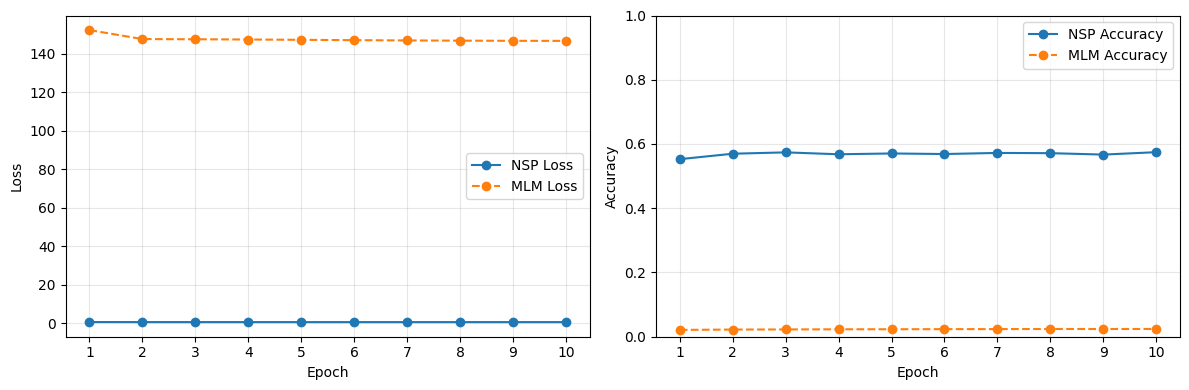

In [44]:
import matplotlib.pyplot as plt
import pandas as pd

# training result
if len(history["nsp_loss"]) == 0:
    raise RuntimeError("history가 비어 있습니다. 바로 위 학습 셀이 정상적으로 실행됐는지 확인해야 합니다.")

history_df = pd.DataFrame(history)
history_df.index = range(1, len(history_df) + 1)
history_df.index.name = "epoch"
print(history_df)

x = history_df.index.to_list()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(x, history_df["nsp_loss"], marker="o", label="NSP Loss")
plt.plot(x, history_df["mlm_loss"], marker="o", linestyle="--", label="MLM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(x)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(x, history_df["nsp_acc"], marker="o", label="NSP Accuracy")
plt.plot(x, history_df["mlm_acc"], marker="o", linestyle="--", label="MLM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(x)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

NSP Loss: 0.675 → 0.639  
NSP Acc : 0.553 → 0.575  
MLM Loss: 152.30 → 146.70  
MLM Acc : 0.021 → 0.024  

In [50]:
# Take one batch from the DataLoader to compute gradients for inspection
if 'train_dataloader' in locals() and train_dataloader is not None:
    pre_train_model.train() # Ensure model is in training mode
    batch_iterator = iter(train_dataloader)
    batch = next(batch_iterator)

    enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch

    enc_tokens_batch = enc_tokens_batch.to(device, dtype=torch.long, non_blocking=True)
    segments_batch = segments_batch.to(device, dtype=torch.long, non_blocking=True)
    labels_nsp_batch = labels_nsp_batch.to(device, dtype=torch.long, non_blocking=True)
    labels_mlm_batch = labels_mlm_batch.to(device, dtype=torch.long, non_blocking=True)

    # Zero gradients before computing new ones
    pre_train_model.zero_grad()

    # Forward pass
    logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

    # Calculate loss
    loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
    loss_mlm = lm_loss(labels_mlm_batch, logits_mlm, ignore_index=0, scale=20.0)

    loss = loss_nsp + loss_mlm

    # Backward pass
    loss.backward()

    print("token emb grad:", pre_train_model.bert.embedding.shared_weights.grad.abs().mean().item())
    print("position emb grad:", pre_train_model.bert.position.embedding.weight.grad.abs().mean().item())
    print("segment emb grad:", pre_train_model.bert.segment.weight.grad.abs().mean().item())
else:
    print("train_dataloader is not defined. Please run the training setup cells first.")

token emb grad: 0.0034947777166962624
position emb grad: 0.002972313202917576
segment emb grad: 0.025810470804572105


Embedding layer가 실제로 학습되는지 확인하기 위해 backward 이후 각 embedding weight의 gradient 평균 절대값을 측정하였다. token embedding, position embedding, segment embedding 모두 0보다 큰 gradient가 확인되었으며, 이를 통해 세 embedding layer가 loss와 연결되어 정상적으로 업데이트되고 있음을 확인하였다.

In [52]:
# ============================================================
# Embedding weight가 실제로 업데이트되는지 확인
# ============================================================

pre_train_model.train()

# 1. 학습 전 embedding weight 저장
before_token_emb = pre_train_model.bert.embedding.shared_weights.detach().cpu().clone()
before_pos_emb = pre_train_model.bert.position.embedding.weight.detach().cpu().clone()
before_seg_emb = pre_train_model.bert.segment.weight.detach().cpu().clone()

# 2. train_dataloader에서 batch 하나만 꺼내기
batch = next(iter(train_dataloader))
enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch

enc_tokens_batch = enc_tokens_batch.to(device, dtype=torch.long)
segments_batch = segments_batch.to(device, dtype=torch.long)
labels_nsp_batch = labels_nsp_batch.to(device, dtype=torch.long)
labels_mlm_batch = labels_mlm_batch.to(device, dtype=torch.long)

# 3. 딱 1 step 학습
optimizer.zero_grad()

logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
loss_mlm = lm_loss(labels_mlm_batch, logits_mlm, ignore_index=0, scale=5.0)

loss = loss_nsp + loss_mlm

loss.backward()
optimizer.step()

# scheduler를 쓰고 있다면 같이 호출
if "learning_rate_scheduler" in globals():
    learning_rate_scheduler.step()

# 4. 학습 후 embedding weight 가져오기
after_token_emb = pre_train_model.bert.embedding.shared_weights.detach().cpu()
after_pos_emb = pre_train_model.bert.position.embedding.weight.detach().cpu()
after_seg_emb = pre_train_model.bert.segment.weight.detach().cpu()

# 5. 변화량 계산
token_diff = (after_token_emb - before_token_emb).abs().mean().item()
pos_diff = (after_pos_emb - before_pos_emb).abs().mean().item()
seg_diff = (after_seg_emb - before_seg_emb).abs().mean().item()

print("1 step 학습 후 embedding 변화량")
print("Token Embedding mean abs diff   :", token_diff)
print("Position Embedding mean abs diff:", pos_diff)
print("Segment Embedding mean abs diff :", seg_diff)

1 step 학습 후 embedding 변화량
Token Embedding mean abs diff   : 1.0136186574527528e-06
Position Embedding mean abs diff: 1.757857717166189e-06
Segment Embedding mean abs diff : 1.5054083633003756e-06


Embedding layer가 실제 optimizer step에 의해 업데이트되는지 확인하기 위해 학습 전 embedding weight를 복사한 뒤, 1 batch에 대해 forward, backward, optimizer.step()을 수행하였다. 이후 학습 전후 embedding weight의 평균 절대 차이를 계산한 결과 0보다 큰 값이 확인되어 token, position, segment embedding이 실제로 학습되고 있음을 확인하였다.